In [83]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap

from glass_dynamics.models.ridge import CustomRidgeRegression

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "W_A_VIF10"

data_path = Path(f"../../data/cassar_split/VIF/{analysis_name}")
plots_path = Path(f"../../plots/{analysis_name}")
model_path = Path(f"../../models/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [84]:
# Data Loading
logger.info("Loading datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0)
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)

X_train = pd.read_parquet(data_path / 'X_train.parquet')
X_test = pd.read_parquet(data_path / 'X_test.parquet')

y_train = pd.read_parquet('../../data/cassar_split/y_train.parquet')
y_test = pd.read_parquet('../../data/cassar_split/y_test.parquet')

# raw_data

[INFO] 2026-06-07 15:20:54 - Loading datasets...


In [85]:
# Convert Oxides to Elements
oxides_duplicated_df = raw_data.drop(columns=['T', 'log_visc'])
oxides_df = oxides_duplicated_df.drop_duplicates().set_index('ID')

atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-06-07 15:20:54 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-06-07 15:20:54 - Successfully converted. Output shape: (847, 59)


In [86]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

,Type,Aggregator,Chemical Property
0,W,Max,GSvolume pa
1,W,Max,NValence
2,W,Max,NdValence
3,W,Max,SpaceGroupNumber
4,W,Max,atomic radius
5,W,Max,atomic volume
6,W,Max,c6 gb
7,W,Max,heat of formation
8,W,Max,num oxistates
9,W,Min,ElectronAffinity


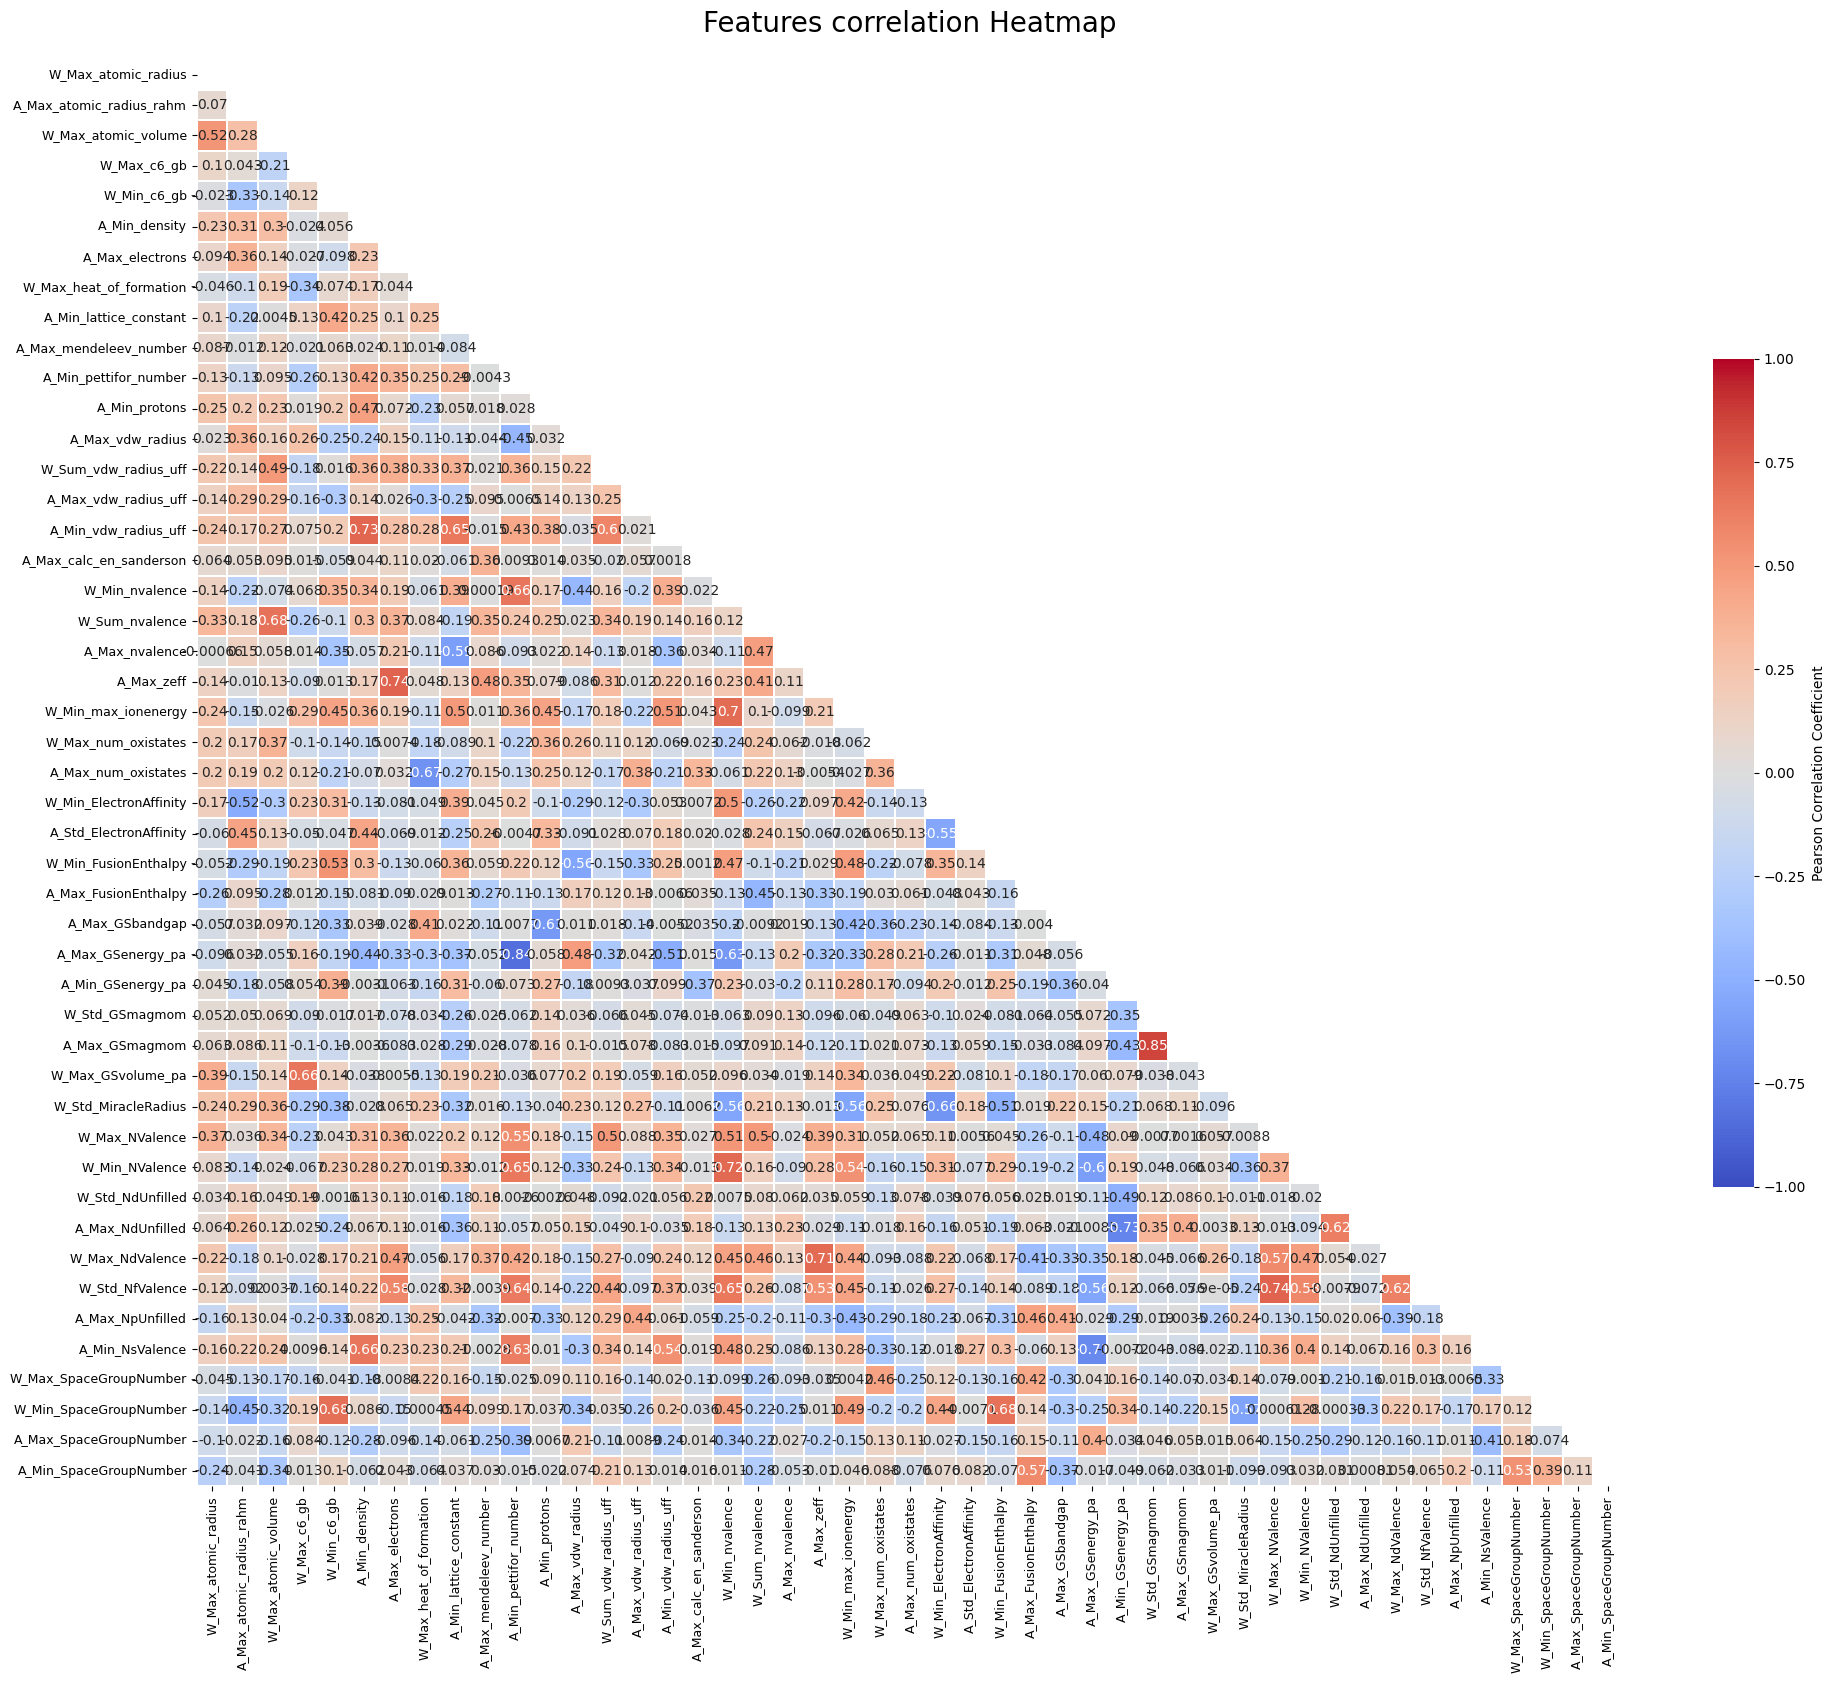

In [87]:
# Selected features visualization
corr_plot = plot_pearson_correlation(X_train_scaled, show_numbers=True)
corr_plot.savefig(plots_path / 'correlation_matrix.pdf', bbox_inches='tight')

df_features = generate_feature_metadata_table(X_train_scaled)
display(df_features[['Type', 'Aggregator', 'Chemical Property']])


In [88]:
# Compute Standard VIF
logger.info("Computing Standard OLS VIF on clustered features...")
X_standard_vif_df = calculate_vif(X_train_scaled)
print("\n--- Standard OLS VIF (Top 10 Worst Features) ---")
print(X_standard_vif_df.head(10))


# Compute Ridge VIF (alpha = 0.1) to see stabilization (Sharma et al. paper)
# logger.info("Computing Ridge VIF (alpha=0,1)...")
# ridge_vif_df = calculate_ridge_vif(X_scaled, alpha=0.1)
# print("\n--- Ridge VIF alpha=0.1 (Top 10 Worst Features) ---")
# print(ridge_vif_df.head(10))

[INFO] 2026-06-07 15:20:59 - Computing Standard OLS VIF on clustered features...
[INFO] 2026-06-07 15:20:59 - Calculating standard OLS VIF for features...

--- Standard OLS VIF (Top 10 Worst Features) ---
                   Feature       VIF
0          W_Std_NfValence  9.799431
1          A_Max_electrons  9.163094
2          A_Max_GSbandgap  9.136273
3           W_Sum_nvalence  9.130736
4  W_Max_heat_of_formation  8.923203
5     A_Min_vdw_radius_uff  8.858937
6   W_Min_ElectronAffinity  8.724051
7            A_Min_protons  8.598934
8          W_Max_NdValence  8.439562
9            A_Min_density  8.283447


[INFO] 2026-06-07 15:20:59 - Computing R and R^2 metrics for 3 targets.
[INFO] 2026-06-07 15:21:00 - Performance metrics computation complete.
[INFO] 2026-06-07 15:21:00 - Rendering performance plots (R, R^2) for Tg_fitted.
[INFO] 2026-06-07 15:21:00 - Rendering performance plots (R, R^2) for m_fitted.
[INFO] 2026-06-07 15:21:01 - Rendering performance plots (R, R^2) for log_eta_inf_fitted.


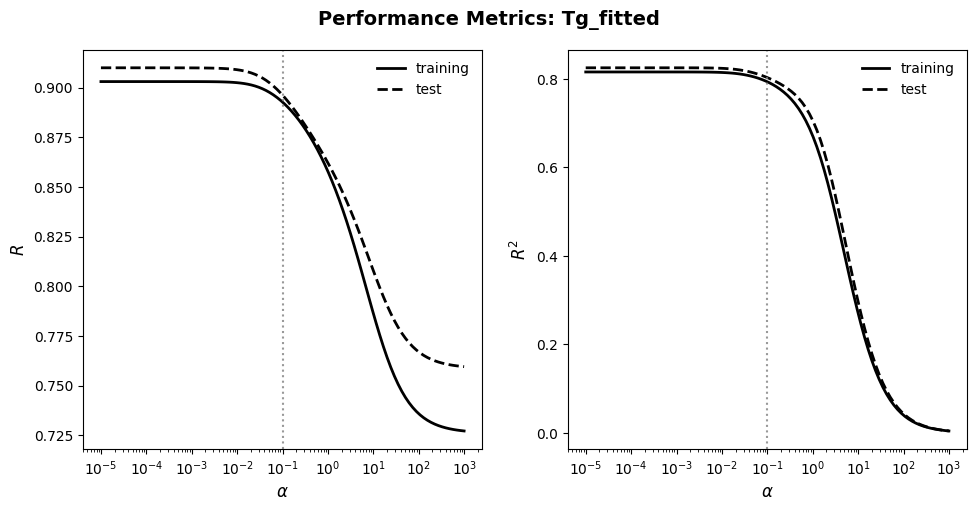

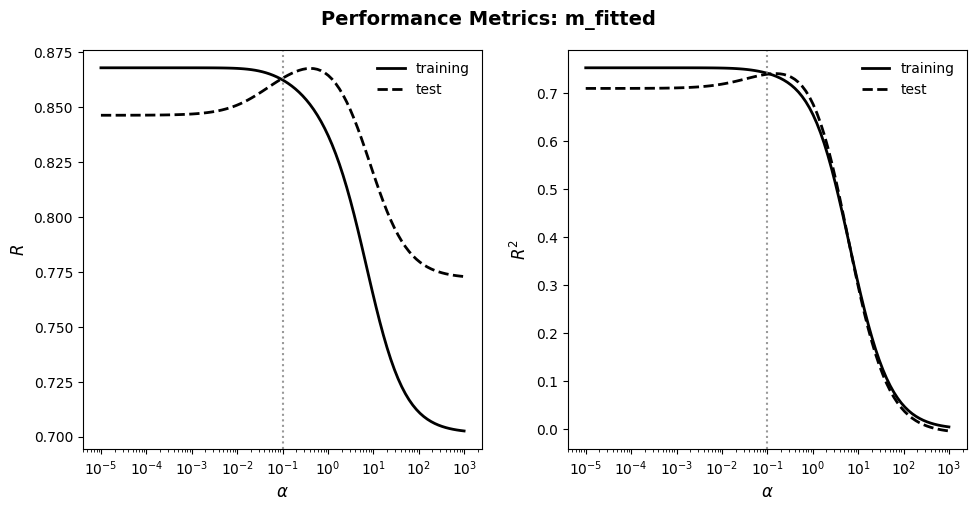

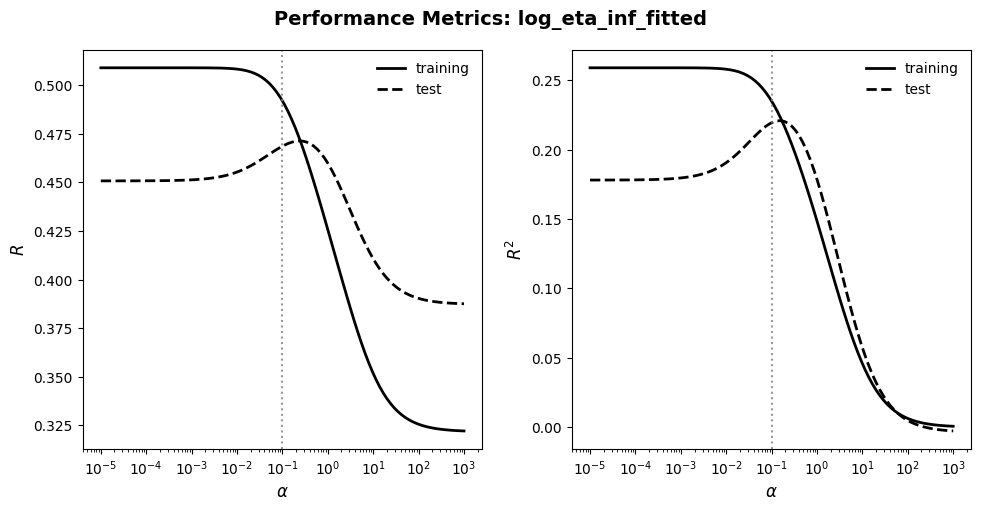

In [89]:
# Model performance analysis as a function of alpha
alphas_spectrum = np.logspace(-5, 3, 100)

performance_results = compute_alpha_performance_metrics(
    X_train_scaled, 
    y_train_scaled, 
    X_test_scaled, 
    y_test_scaled, 
    alphas_spectrum
)

performance_plots_path = plots_path / "performance_plots"
performance_plots_path.mkdir(parents=True, exist_ok=True)

for target in performance_results.keys():
    fig = plot_target_performance(
        performance_results[target],
        target_name=target,
        ref_alpha=0.1
    )
    fig.savefig(performance_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-06-07 15:21:04 - Computing robust weight traces across 40 alphas.
[INFO] 2026-06-07 15:21:04 - Averaging over 20 random splits (test_size=0.5).
[INFO] 2026-06-07 15:21:05 - Robust traces computation completed. Packaging results.
[INFO] 2026-06-07 15:21:05 - Rendering robust normalized traces for target: Tg_fitted
[INFO] 2026-06-07 15:21:05 - Rendering robust normalized traces for target: m_fitted
[INFO] 2026-06-07 15:21:06 - Rendering robust normalized traces for target: log_eta_inf_fitted


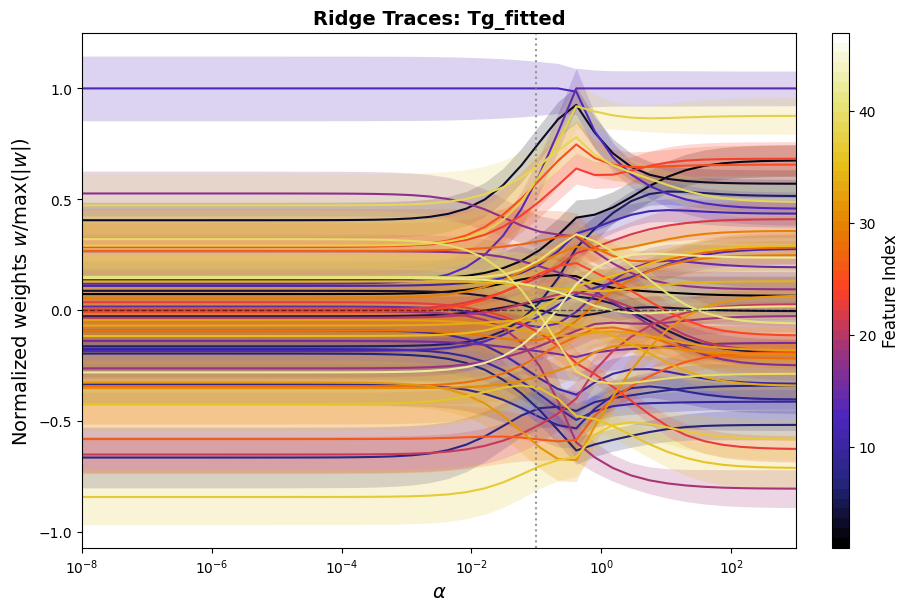

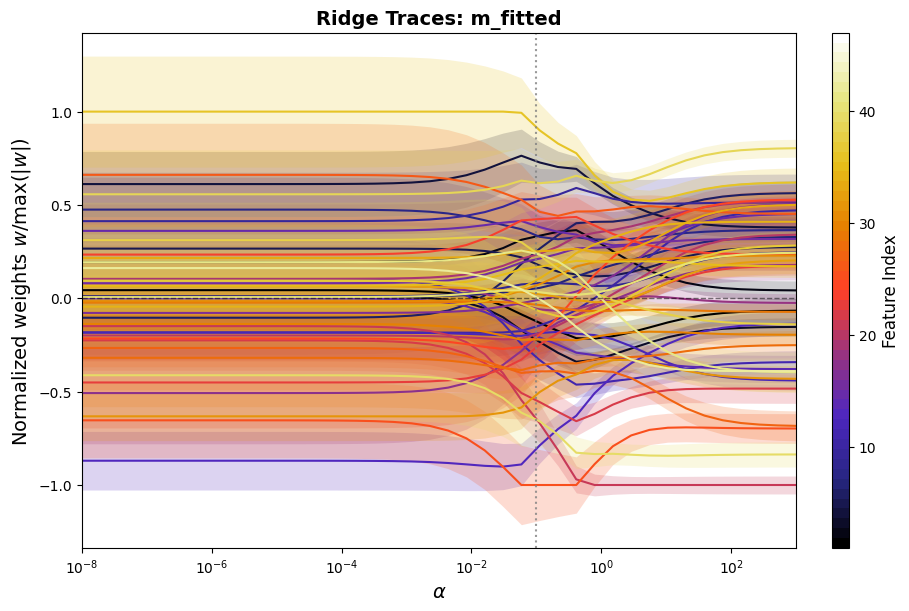

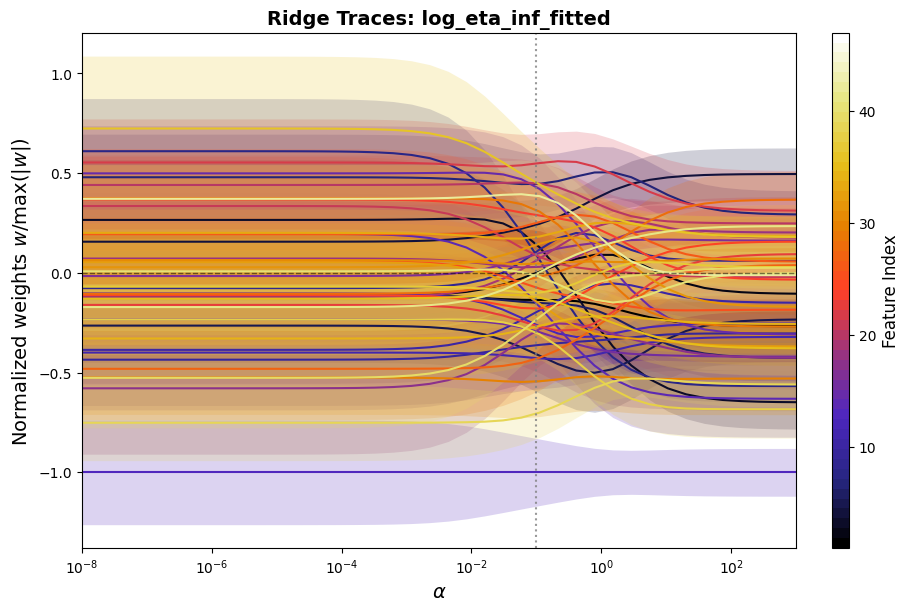

In [90]:
# Features weights analysis in relation to alpha
traces_alphas_spectrum = np.logspace(-8, 3, 40)

robust_traces = compute_weight_traces(
    X=X_train_scaled,
    y=y_train_scaled,
    alphas=traces_alphas_spectrum,
    n_splits=20,
    test_size=0.5
)

target_names = list(robust_traces.keys())

traces_plots_path = plots_path / "traces_plots"
traces_plots_path.mkdir(parents=True, exist_ok=True)

for target in target_names:
    mean_df = robust_traces[target]["mean_weights"]
    std_df = robust_traces[target]["std_weights"]

    fig = plot_normalized_traces(
        mean_weights=mean_df,
        std_weights=std_df,
        target_name=target
    )
    fig.savefig(traces_plots_path / f"{target}.pdf", bbox_inches='tight')

[INFO] 2026-06-07 15:21:08 - Extracting raw feature importance at alpha=0.1 over 100 splits.
[INFO] 2026-06-07 15:21:08 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,W_Sum_vdw_radius_uff,13,0.278016,0.028563,0.278016
1,W_Max_atomic_volume,2,0.209570,0.024543,0.209570
2,W_Std_NfValence,40,-0.202001,0.031354,0.202001
3,A_Min_NsValence,42,0.173016,0.026110,0.173016
4,A_Max_NpUnfilled,41,0.170267,0.030035,0.170267
5,W_Std_MiracleRadius,34,-0.170048,0.025055,0.170048
6,A_Max_FusionEnthalpy,27,0.164190,0.031357,0.164190
7,A_Max_GSbandgap,28,-0.160066,0.027146,0.160066
8,A_Max_vdw_radius_uff,14,0.158145,0.021356,0.158145
9,W_Max_num_oxistates,22,-0.136214,0.026632,0.136214


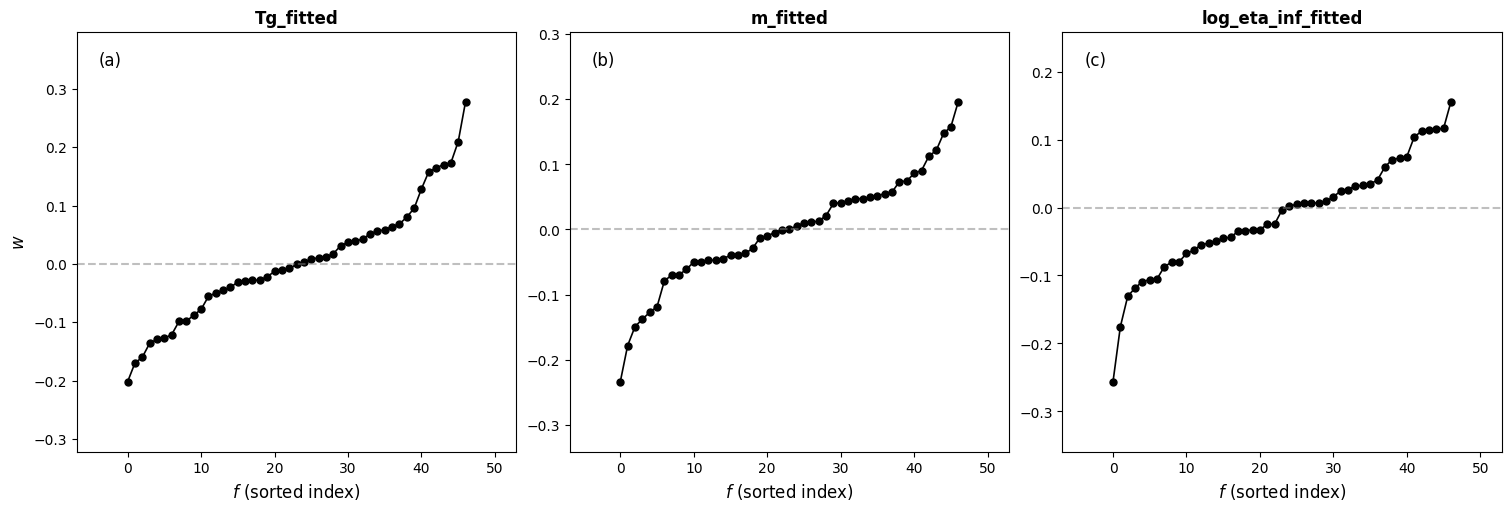

In [91]:
# Feature weights plots (ordered)
importance_data = extract_importance(
    X=X_train_scaled,
    y=y_train_scaled,
    alpha=0.1,
    n_splits=100,
    sort_by='magnitude' # <- Ordina per il peso più forte, a prescindere dal segno
)

fig_importance = plot_sorted_feature_importance(importance_data, top_n=0)
fig_importance.savefig(plots_path / 'features_importance_ridge.pdf', bbox_inches='tight')


importance_data['Tg_fitted'].head(10)
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

[INFO] 2026-06-07 15:21:10 - Tracking evolution of top 5 features (identified at alpha=0.1).
[INFO] 2026-06-07 15:21:10 - Rendering evolution plots, highlighting 3 alphas.


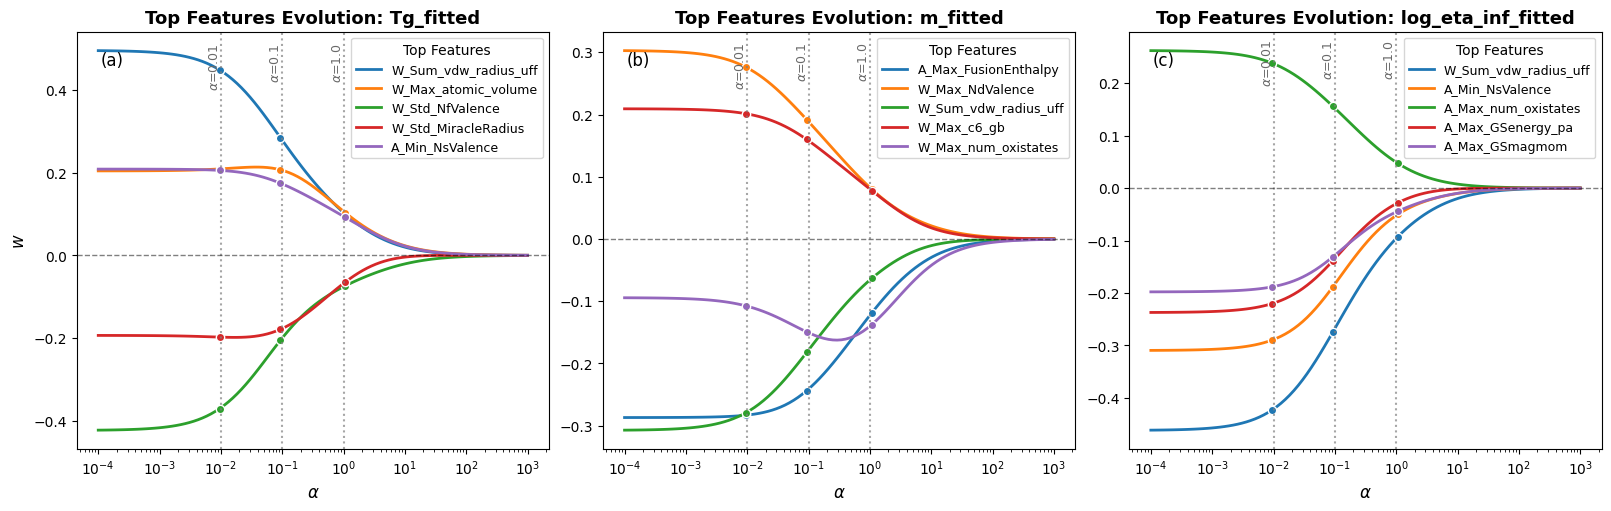

In [92]:
# Top features analisys

alphas_spectrum = np.logspace(-4, 3, 100)

evolution_data = extract_top_features_evolution(
    X=X_train_scaled,
    y=y_train_scaled,
    alphas=alphas_spectrum,
    ref_alpha=0.1,
    top_n=5
)

selected_alphas = [0.01, 0.1, 1.0]

fig_evolution = plot_top_features_evolution(
    evolution_dict=evolution_data,
    highlight_alphas=selected_alphas
)

fig_evolution.savefig(plots_path / 'top_features_evolution.pdf', bbox_inches='tight')

In [93]:
# Training model

# Instantiate the model with alpha = 0.1
ridge_model = CustomRidgeRegression(alpha=0.1, fit_intercept=True)

# Fit the model on the training data
ridge_model.fit(X_train_scaled, y_train_scaled)

pickle.dump(ridge_model, open(model_path / "ridge_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")

[INFO] 2026-06-07 15:21:12 - Model successfully trained and saved!


In [94]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

evaluation_metrics = evaluate_final_model(
    model=ridge_model,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    target_cols=target_columns,
    y_scaler=y_scaler
)

[INFO] 2026-06-07 15:21:12 - Evaluating model on the unseen Test Set (85 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg
  Pearson : 0.896
  R^2     : 0.803
  RMSE    : 0.419
  MAE     : 0.311
  MedAE   : 0.253
--------------------------------------------------
Target: m
  Pearson : 0.863
  R^2     : 0.740
  RMSE    : 0.525
  MAE     : 0.415
  MedAE   : 0.348
--------------------------------------------------
Target: log_eta_inf
  Pearson : 0.469
  R^2     : 0.219
  RMSE    : 0.821
  MAE     : 0.603
  MedAE   : 0.500
--------------------------------------------------
[INFO] 2026-06-07 15:21:12 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.918
  R^2     : 0.787
  RMSE    : 1.867
  MAE     : 1.075
  MedAE   : 0.583
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
--------------------------------------------------
  Pearson : 

[INFO] 2026-06-07 15:21:13 - Rendering 2D density correlation plot with residual inset.


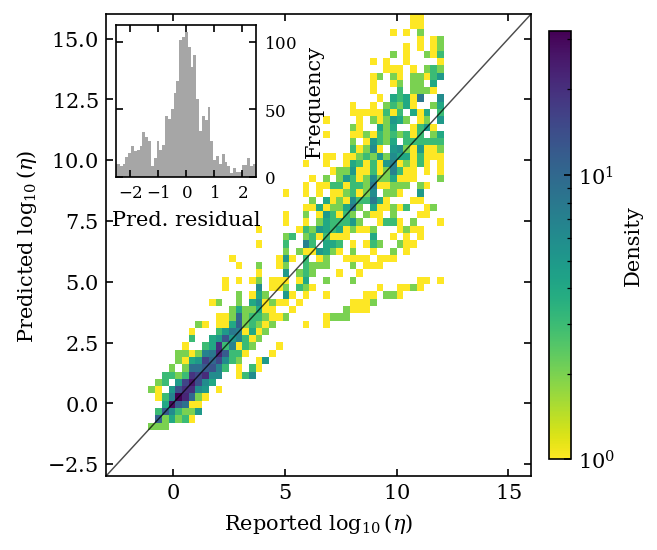

In [95]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-06-07 15:21:15 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,709,1Al₂O₃.50P₂O₅.18SrO.31ZnO,2.010101,14.438376
1,806,51Li₂O.49P₂O₅,1.196148,4.497942
2,449,10MnO.20Na₂O.70SiO₂,0.276923,4.091483
3,265,15Al₂O₃.65B₂O₃.20CaO,0.151111,3.893198
4,26,9Al₂O₃.6B₂O₃.1BaO.12K₂O.19MgO.53P₂O₅,3.864145,3.760267
5,220,74B₂O₃.16BaO.10La₂O₃,1.110106,3.610022
6,322,8Al₂O₃.3K₂O.4Na₂O.5P₂O₅.81SiO₂,0.551878,2.884761
7,293,20BeO.60GeO₂.20Na₂O,0.410256,2.826124
8,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,2.703794
9,428,15Na₂O.27PbO.58SiO₂,0.095810,2.688246


[INFO] 2026-06-07 15:21:15 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


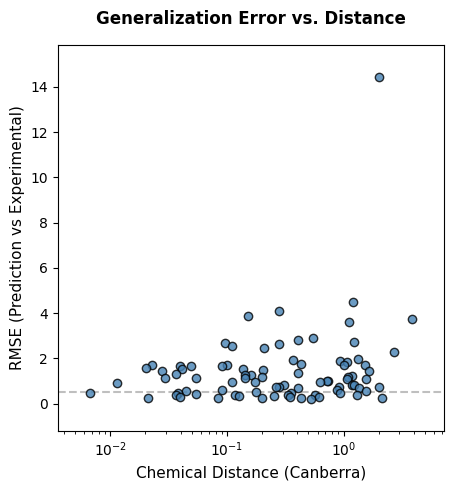

In [96]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = ridge_model.predict(X_test_scaled)
y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-06-07 15:21:16 - Training ensemble of 100 bootstrap models...
[INFO] 2026-06-07 15:21:16 - Rendering bootstrap prediction grids for 85 glasses.


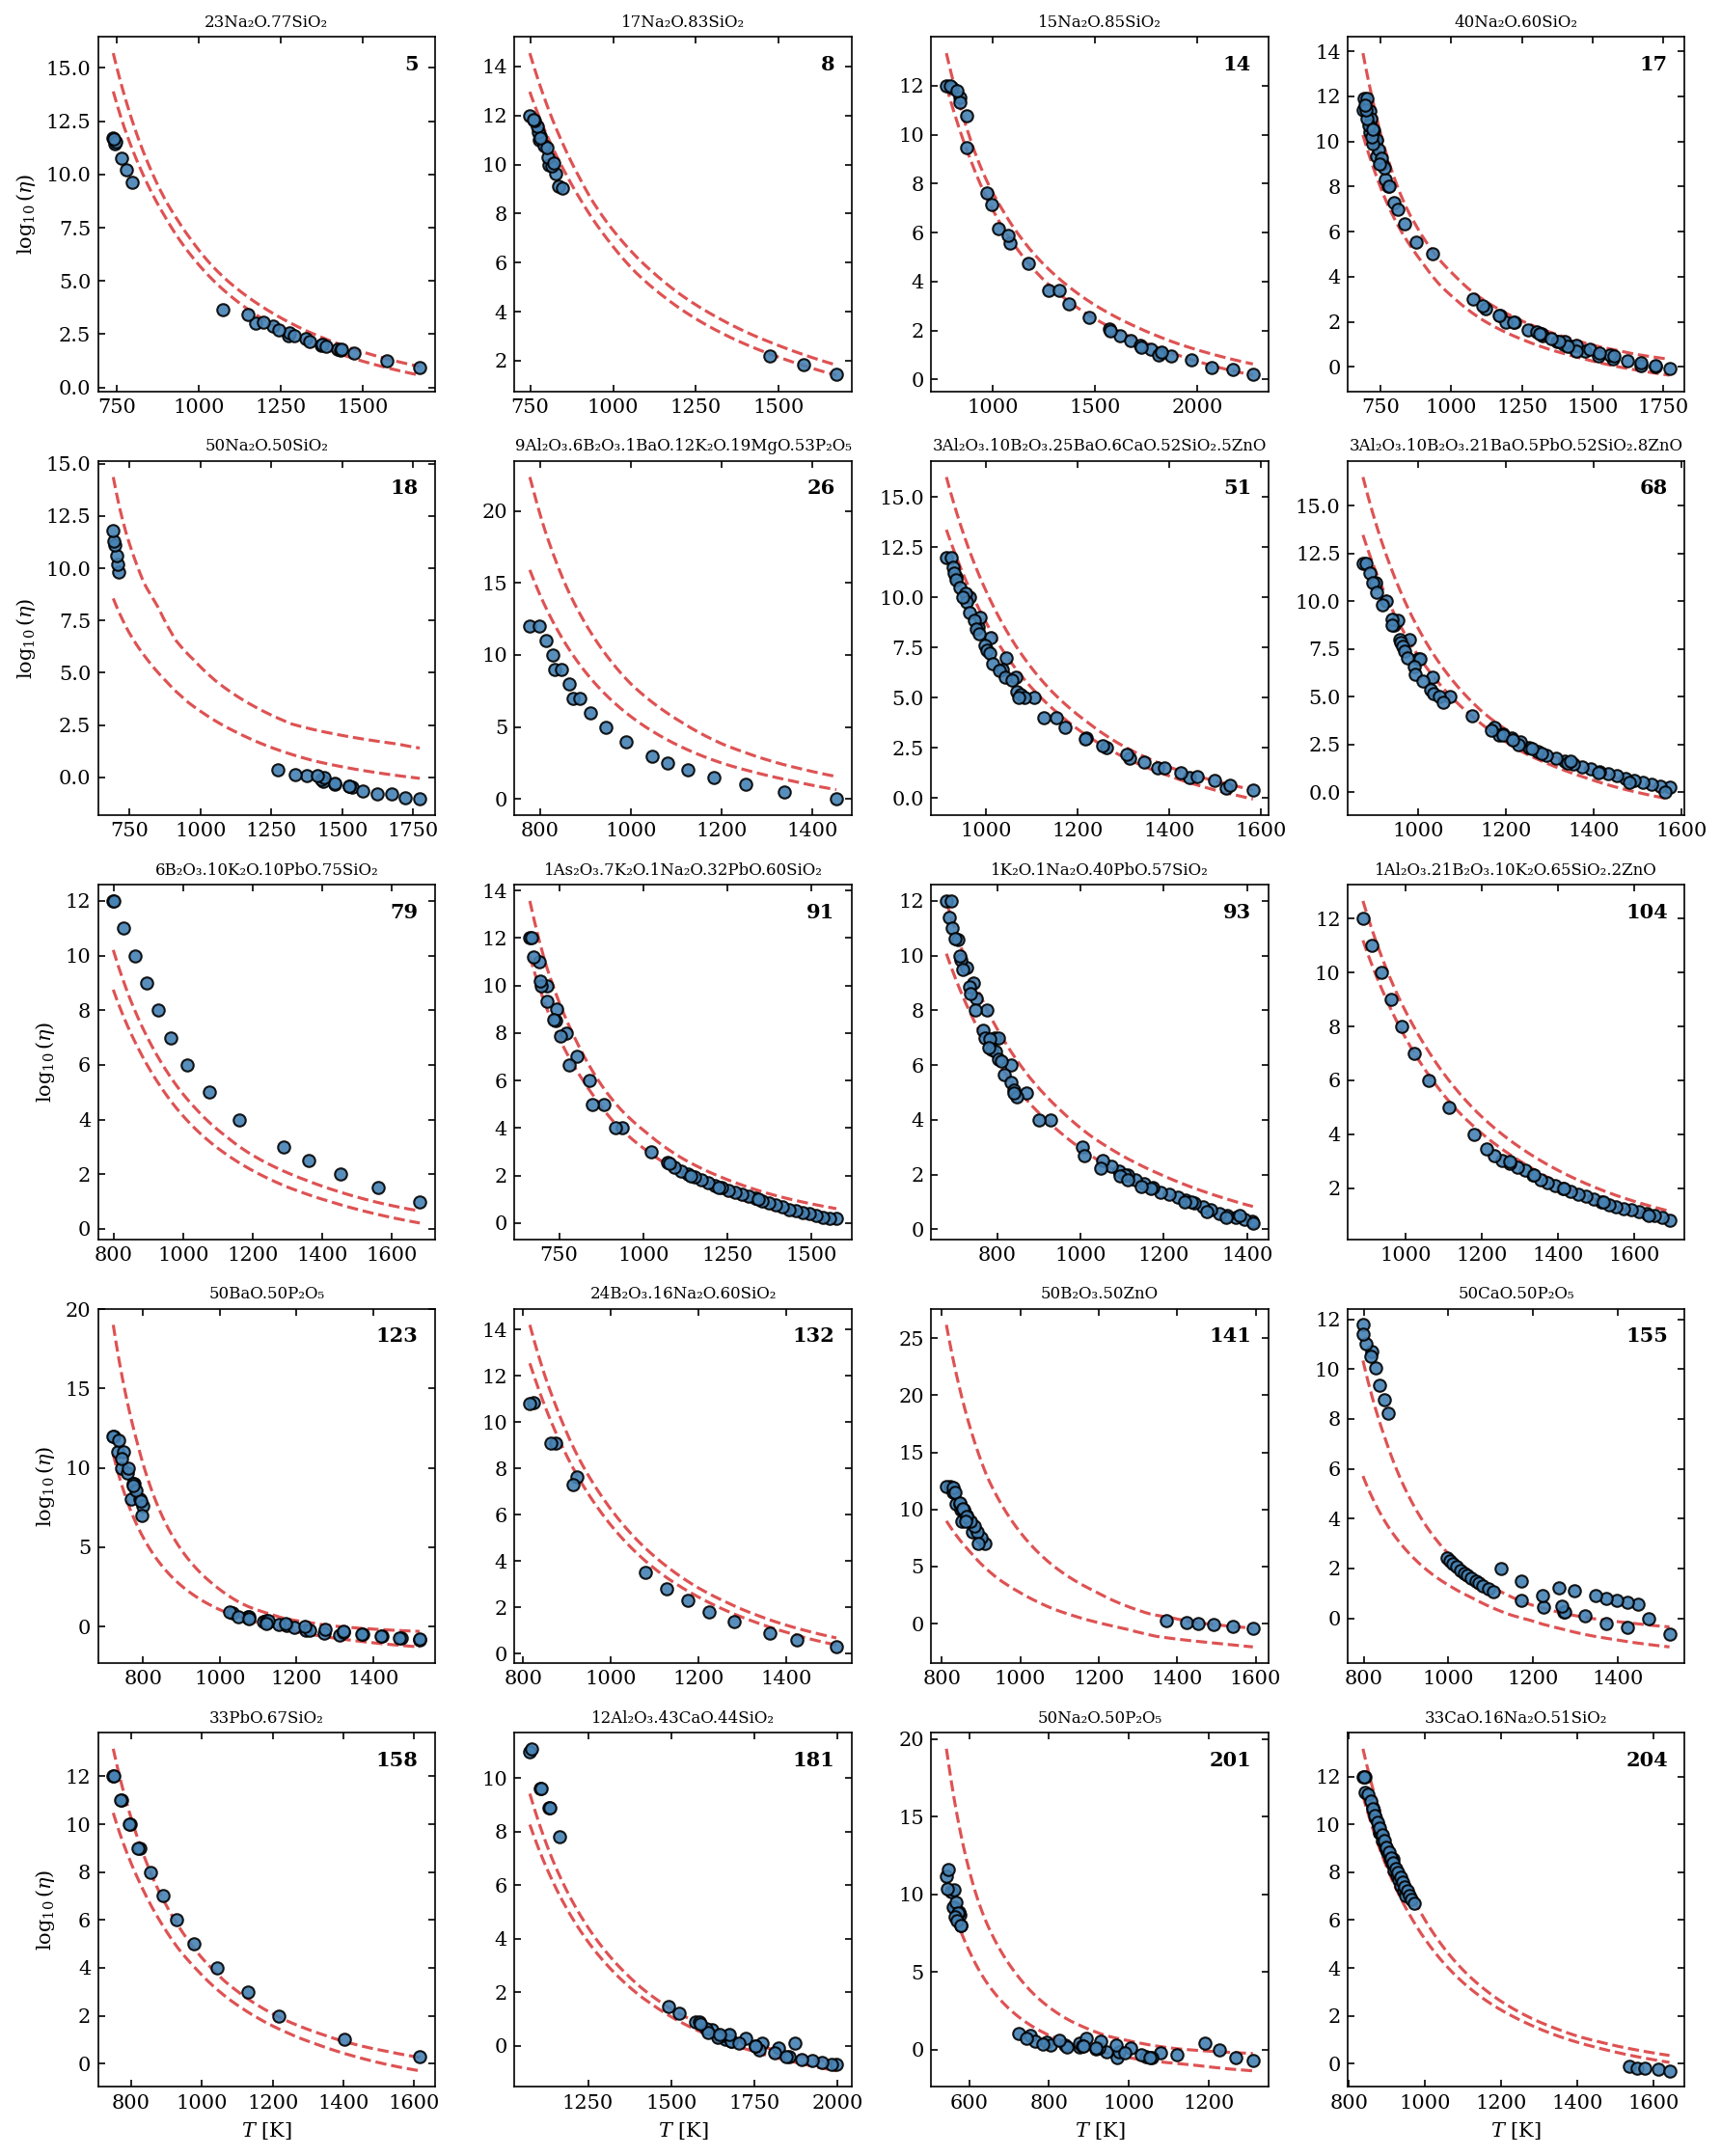

In [97]:
# Plotting test liquids viscosities with uncertainty bars

base_ridge = CustomRidgeRegression(alpha=0.1, fit_intercept=True)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=base_ridge,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)